# **Crop Recommendation Analysis**

## **Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df=pd.read_csv('/content/Crop_recommendation.csv')

## **Cleaning & Investigating Dataset**

### Data Preview

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


### Checking Missing Values

In [5]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


### Checking Duplicated Values

In [6]:
print(df.duplicated().sum())

0


## **Feature Engineering**

### 1. Total Nutrients (N + P + K)

In [7]:

df['Total_Nutrients'] = df['N'] + df['P'] + df['K']
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label,Total_Nutrients
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162


### 2. Nutrient Ratios (N/P, N/K, P/K)

In [8]:
epsilon = 1e-6
df['N_P_Ratio'] = df['N'] / (df['P'] + epsilon)
df['N_K_Ratio'] = df['N'] / (df['K'] + epsilon)
df['P_K_Ratio'] = df['P'] / (df['K'] + epsilon)
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label,Total_Nutrients,N_P_Ratio,N_K_Ratio,P_K_Ratio
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,2.142857,2.093023,0.976744
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,1.465517,2.073171,1.414634
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,1.090909,1.363636,1.250000
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,2.114286,1.850000,0.875000
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,1.857143,1.857143,1.000000


### 3. Temperature-Rainfall Ratio (Rainfall / Temperature)

In [9]:
epsilon = 1e-6
df['Moisture_Index'] = df['rainfall'] / (df['temperature'] + epsilon)
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label,Total_Nutrients,N_P_Ratio,N_K_Ratio,P_K_Ratio,Moisture_Index
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,2.142857,2.093023,0.976744,9.719254
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,1.465517,2.073171,1.414634,10.411149
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,1.090909,1.363636,1.250000,11.474481
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,2.114286,1.850000,0.875000,9.167760
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,1.857143,1.857143,1.000000,13.050921


### 4. Soil pH Categorization

In [10]:
conditions = [(df['ph'] < 6.0),
              (df['ph'] >= 6.0) & (df['ph'] <= 7.5),
              (df['ph'] > 7.5)]
choices = ['Acidic', 'Neutral', 'Alkaline']
df['ph_category'] = np.select(conditions, choices, default='Unknown')
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label,Total_Nutrients,N_P_Ratio,N_K_Ratio,P_K_Ratio,Moisture_Index,ph_category
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,2.142857,2.093023,0.976744,9.719254,Neutral
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,1.465517,2.073171,1.414634,10.411149,Neutral
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,1.090909,1.363636,1.250000,11.474481,Alkaline
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,2.114286,1.850000,0.875000,9.167760,Neutral
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,1.857143,1.857143,1.000000,13.050921,Alkaline


### 5. Temperature-Humidity Index (THI)

In [11]:
df['THI'] = df['temperature'] + (0.55 * df['humidity'])
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label,Total_Nutrients,N_P_Ratio,N_K_Ratio,P_K_Ratio,Moisture_Index,ph_category,THI
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,2.142857,2.093023,0.976744,9.719254,Neutral,65.981253
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,1.465517,2.073171,1.414634,10.411149,Neutral,65.946266
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,1.090909,1.363636,1.250000,11.474481,Alkaline,68.280879
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,2.114286,1.850000,0.875000,9.167760,Neutral,70.578196
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,1.857143,1.857143,1.000000,13.050921,Alkaline,65.012855


### 6. Nutrient-to-Water Ratio (Total_Nutrients / Rainfall)

In [12]:
epsilon = 1e-6
df['Nutrient_to_Water_Ratio'] = df['Total_Nutrients'] / (df['rainfall'] + epsilon)
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label,Total_Nutrients,N_P_Ratio,N_K_Ratio,P_K_Ratio,Moisture_Index,ph_category,THI,Nutrient_to_Water_Ratio
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,2.142857,2.093023,0.976744,9.719254,Neutral,65.981253,0.862343
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,1.465517,2.073171,1.414634,10.411149,Neutral,65.946266,0.811805
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,1.090909,1.363636,1.250000,11.474481,Alkaline,68.280879,0.602354
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,2.114286,1.850000,0.875000,9.167760,Neutral,70.578196,0.613512
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,1.857143,1.857143,1.000000,13.050921,Alkaline,65.012855,0.616632


## **Exploratory Data Analysis (EDA)**

In [14]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall,Total_Nutrients,N_P_Ratio,N_K_Ratio,P_K_Ratio,Moisture_Index,THI,Nutrient_to_Water_Ratio
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,152.063636,1.701689,1.670538,1.668555,4.226488,64.931222,1.983165
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,79.918669,2.573334,1.507555,1.197217,2.369214,14.179072,1.587046
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,17.000000,0.000000,0.000000,0.090909,0.680956,25.099580,0.150878
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,94.000000,0.350000,0.559706,0.697874,2.268611,58.307022,0.812168
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,146.000000,0.890909,1.388322,1.262531,3.892046,68.207830,1.650233
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,179.000000,1.977399,2.167453,2.588235,5.479247,73.918277,2.506702
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,385.000000,23.799995,9.333333,5.999999,14.196465,95.090732,9.106739


### 1. Numerical Column Distributions

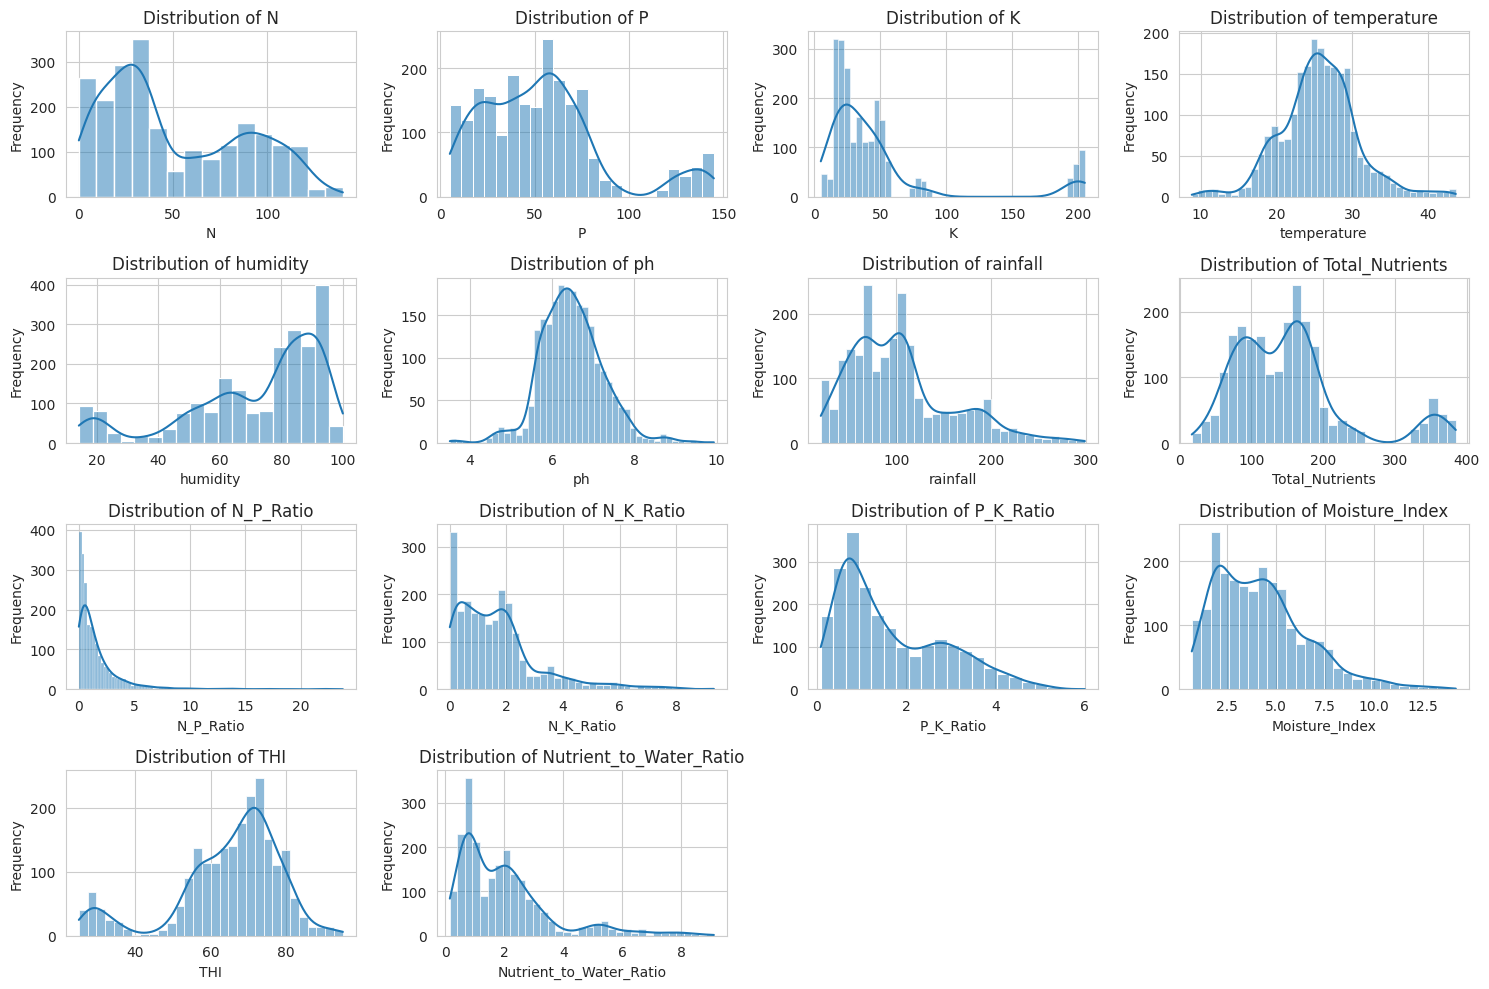

In [15]:
numerical_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 2. Correlation Heatmap

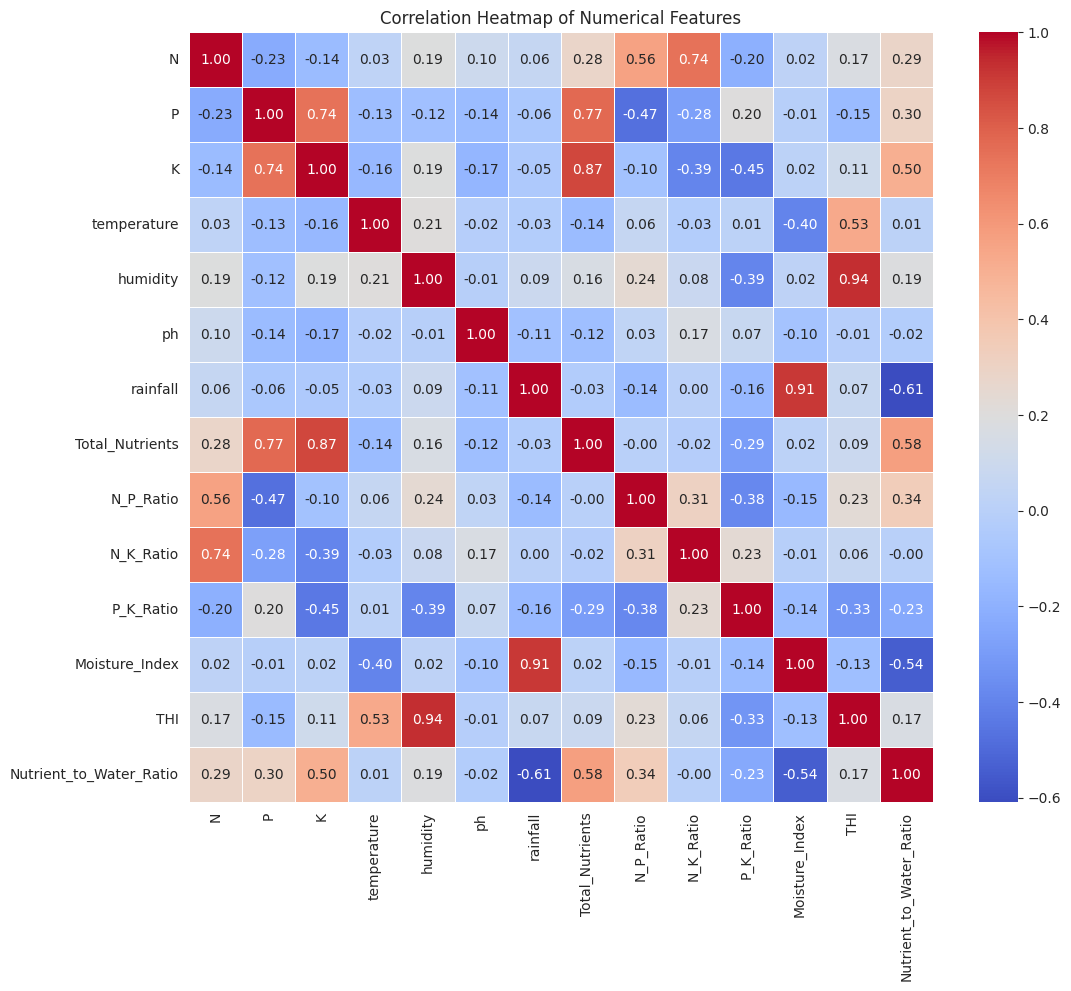

In [16]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

* Humidity & THI: Humidity is almost perfectly correlated with the THI (Temperature-Humidity Index) (0.94), showing that humidity is the primary driver of heat stress in this dataset

### 3. Checking Outliers

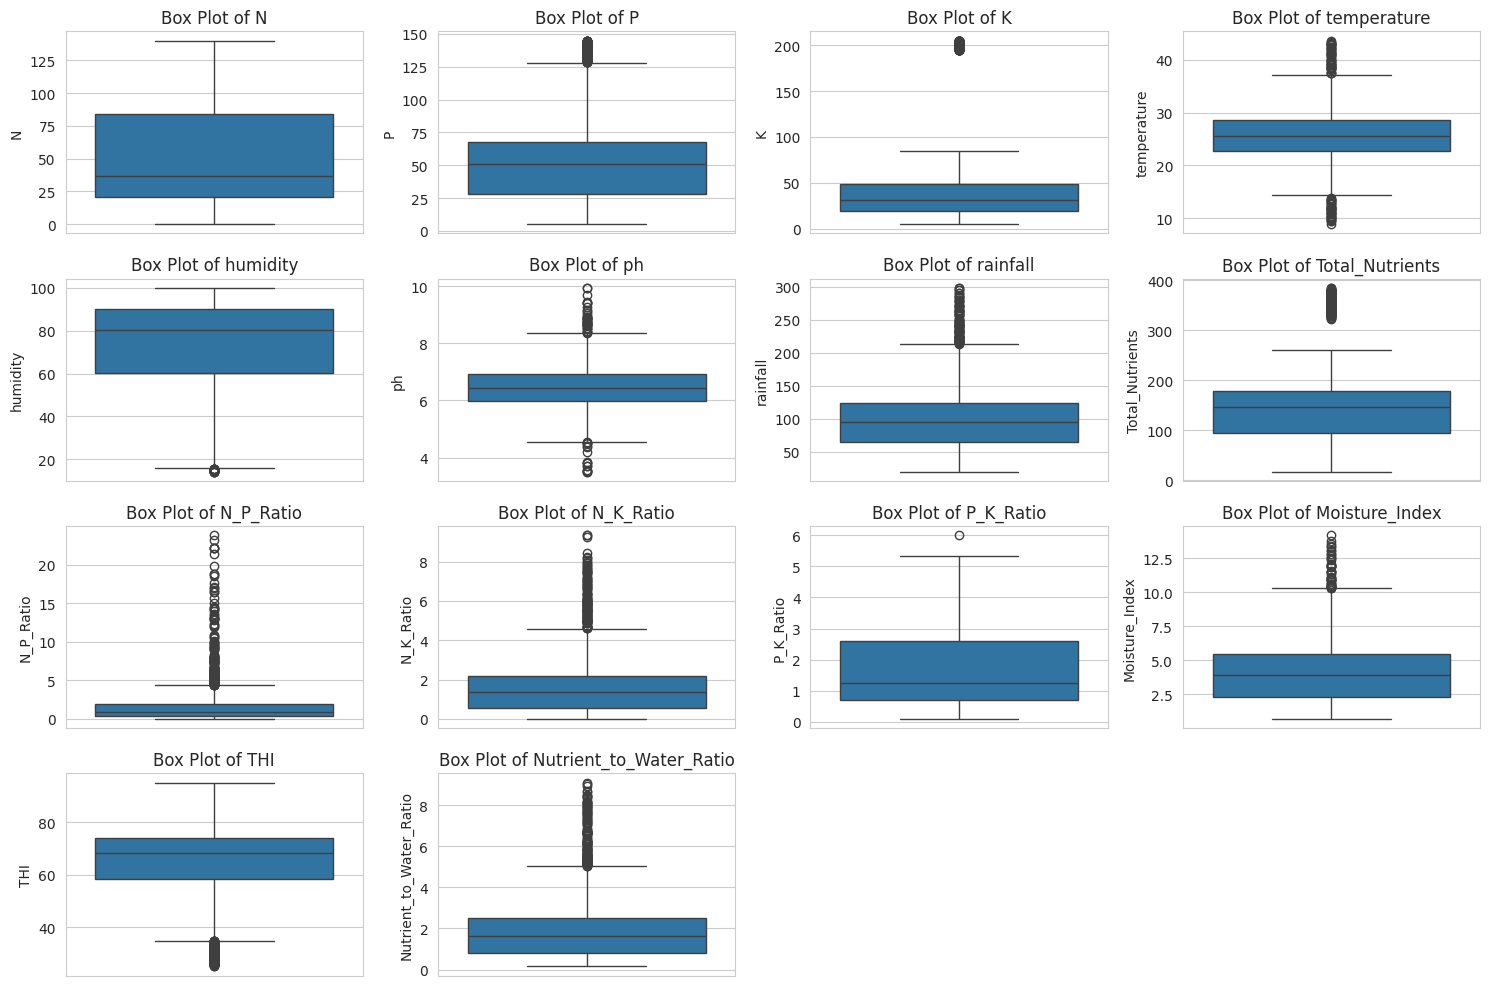

In [17]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Nutrient Requirements by Crop (Top 5)

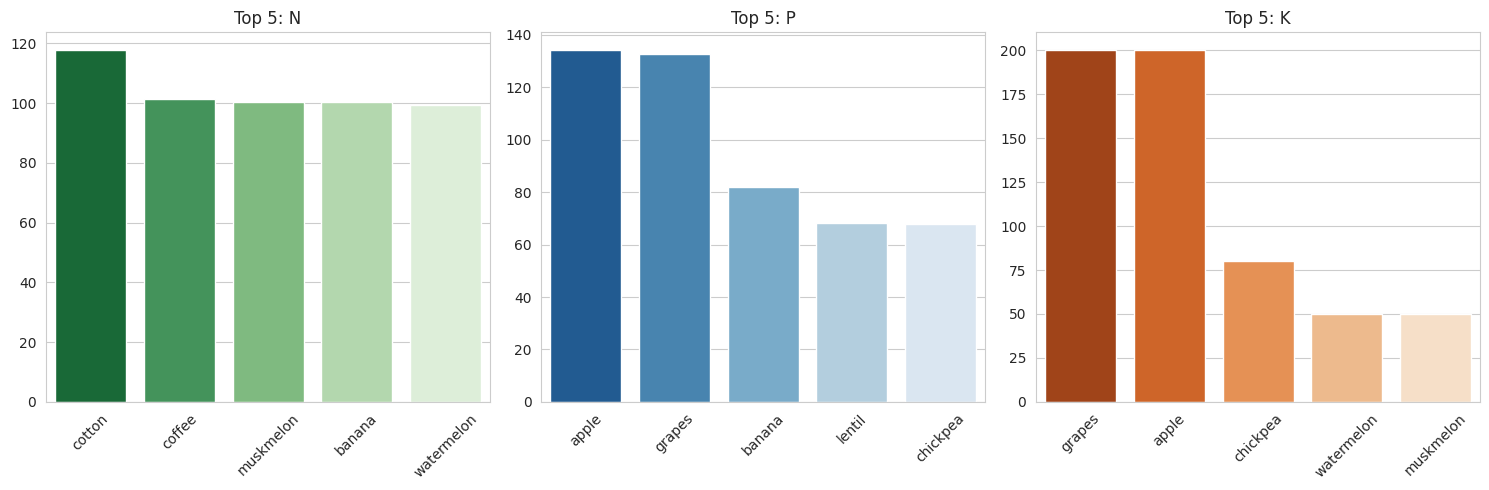

In [28]:
crop_means = df.groupby('label').mean(numeric_only=True)

plt.figure(figsize=(15, 5))
nutrients = ['N', 'P', 'K']
colors = ['Greens_r', 'Blues_r', 'Oranges_r']

for i, nutrient in enumerate(nutrients):
    plt.subplot(1, 3, i + 1)
    data = crop_means[nutrient].sort_values(ascending=False).head(5)
    sns.barplot(x=data.index, y=data.values, palette=colors[i], hue=data.index, legend=False)
    plt.title(f'Top 5: {nutrient}')
    plt.xticks(rotation=45)
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [29]:
df.to_csv('Cleaned_Crops',index = False)